# Mapping surface height dynamics to subsurface flow physics in free-surface turbulent flow using SHRED - Code tutorial

This notebook illustrates step-by-step how the results and plots are generated. The notebook runs all the necessary plots, given the folder structure, and files, are correctly set up. This Notebook uses functions and programs that are saved in .py files. For details behind the results, check out these files.

Note, the pre-processing of datasets, especially for big datasets like the DNS, takes time and a lot of space. Do this once and save files in the correct folder. 

# Loading files and libraries

In [2]:
import numpy as np
import processdata       #this file contains all function for the processing, including how to run SHRED, calculate error metrics
import plot_results   #file with plotting functions
import utilities        #file with different utility functions
import models           #file includes the SHRED model


# Pre-processing, loading data files etc

Before starting, we must ensure all data is loaded correctly. Data from the DNS cases and the experimental cases from the so-called 'T-tank' are saved locally. These should be stored in /data/DNS/raw/ or /data/exp/raw/. 

### DNS
For the DNS data, each horizontal velocity plane, as well as surface profilometry, is stored as one .mat file each, as an array of shape (dimX, dimY, dimT), where X and Y are spatial dimensions, and T is time. 

In [ ]:
'''READING DNS DATA'''

#DNS_case = 'RE1000' #corresponds to case S1
DNS_case = 'RE2500' #corresponds to case S2

#specify plane (1=surface, 1> subsurface)
plane = 1 # 1-55 for S1, 1-76 for S2

#specify address: if not given, it will be stored under data/DNS/raw/



#reading u_fluc, the velocity fluctuation, of the given velocity plane
u_fluc = utilities.get_velocity_plane_DNS(DNS_case, plane)


#get surface elevation

surf_fluc = utilities.get_surface_DNS(DNS_case)

### Experiment
For the experimental data, we assume all files in .mat file. In the case of the experimental 'T-tank' data, there are 5 PIV velocity planes, named [H395, H390, H375, H350, H300], where the number represents the mm height from a reference level, and surface reference is at 400 mm, i.e. H390 is 1 cm below surface, H300 is 10 cm below surface.  Note that only the last 4 are used, as the first plane is noisy. For this experiment, surface profilometry can only be done simultaneously with one unique PIV velocity plane, hence there is one profilometry .mat file for every velociy plane. The profilometry data is labeled with the variable name "eta", due to the convension of naming the surface elevation $\eta$. .

Each mat file contains array of shape (num_ens, dimX, dimY, dimT), where num_ens is the number of instances in the experimental ensemble run. For T-tank, this is 20.

In [ ]:
'''READING EXPERIMENTAL DATA'''
case = 'P50'    #corresponds to case E2
#case = 'P25'    #corresponds to case E1
plane_index = 2 #'H390'  #H300, H350, H375, H390, H395
depths = ['H395', 'H390', 'H375', 'H350', 'H300']
depth=depths[plane_index-1]

u_fluc_exp = utilities.get_velocity_plane_exp(case,plane_index)

surf_fluc_exp = utilities.get_surface_exp(case, depth)

# Data compression

As highlighted in the paper, in particular Section III B, we use the Singular Value Decomposition (SVD) to decompose the surface and velocity fields and work in the compressed space in the reconstruction. 


In the following cell, we calculate the SVD modes and store the **U**, **S** and **V** matrices in files. 

In [ ]:
'''calculate and save SVD matrices'''


DNS = True
DNS_case = 'RE1000'
DNS_plane = 1


experimental_ens = 3 
experimental_case='P50'
plane=2

utilities.save_svd_full(surf_fluc, u_fluc, experimental_ens, experimental_case, DNS=DNS, DNS_plane=DNS_plane, DNS_case=DNS_case)

#save all singular values for usage
if DNS:
    utilities.save_singular_values_full(DNS_case, DNS_plane)
else:
    utilities.save_singular_values_full_exp(experimental_case, experimental_ens, plane)


### Compressing DNS Case S2


In the following cell, we execute the function for calculating certain SVD modes, the singular value profile and turbulent spectra for different ranks, to reproduce Figs. 3 and 4 in the paper. 

L_INT:  0.6388345417144542


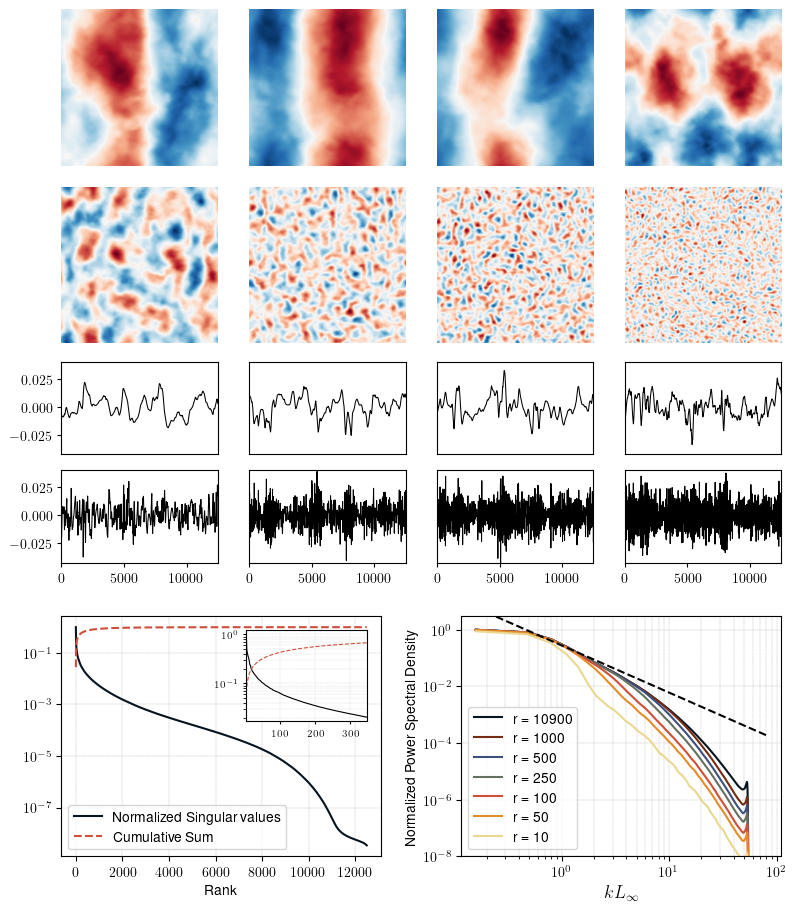

In [2]:
case='S2'                       
plane=1                                 #horizontal plane of choice -- for case S1: planes between [1, 57], for S2: [1,76]
rank_list=[10900,1000,500,250,100,50,10] #list of ranks for the spectral plot
labels=rank_list                        #make string labels for the ranks for the spectral plot
mode_list = [0,1,2,9,49,249,499,999]    #list of rank modes for the plots of U and V modes


plot_results.plot_svd_and_spectra_DNS(case,plane, rank_list, mode_list, labels)

### Compressing Experimental Case E2

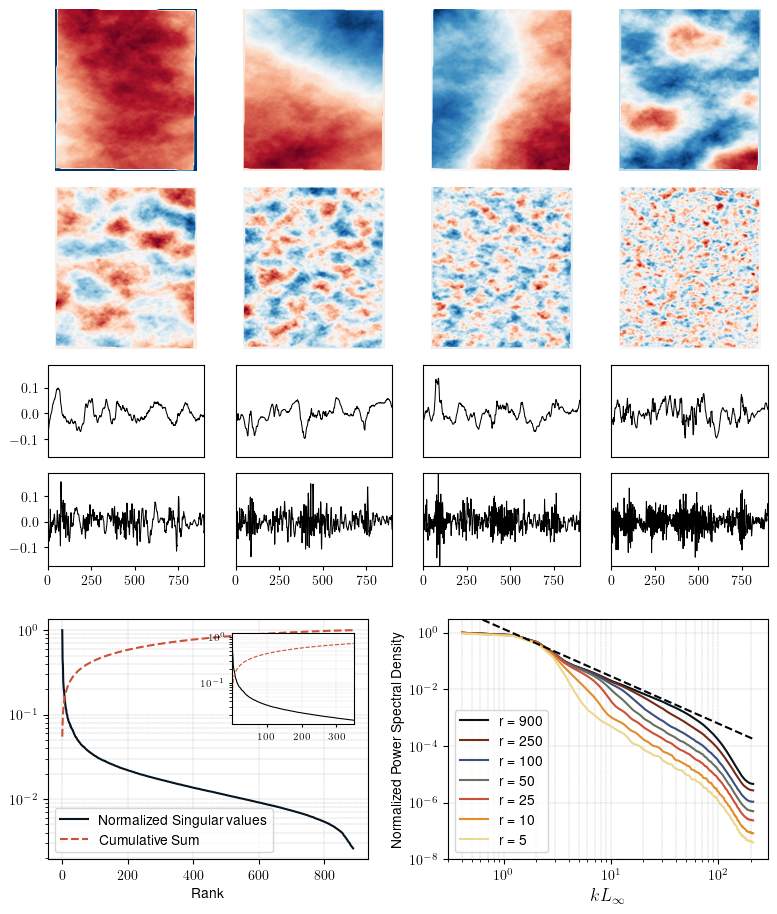

In [3]:
case='E2'
plane=3
rank_list = [900,250,100,50,25,10,5]
labels=rank_list
mode_list=[0,1,2,9,24,49,99,249]
ensembles=[3]

plot_results.plot_svd_and_spectra_exp(case,plane, rank_list, mode_list, labels, ensembles)

## **Run SHRED**

When executing SHRED, we decide how many planes to feed in, what case to run for, what rank compression we apply to the input, how many sensor to use and how many SHRED ensemble runs we want. 

### SHRED DNS CASE S2

Here we run SHRED for only two planes (plane 10, roughly $0.2 L_{\infty}$ deep, and plane 70 roughly $1.8 L_{\infty}$ deep). We run only one ensemble case for this test case

In [ ]:
'''INPUT PARAMETERS'''
case='S1' 

full_planes=False              #if all planes included, set this to True. 
vel_planes_selective = [1,6,11,16,21,26,31,36,41,46,51,56]#,61,66,71,76]      #else, we choose specific planes

num_sensors = 3   #number of sensors for surface measurement. Standard is 3.
ens_start=111 #start index for first SHRED ensemble (can be 0)
ens_end=129  #last index for SHRED ensemble
lags=52     #lags for the LSTM, standard is 52      
random_sampling=True    #if True, snapshots are randomly exctracted and separated to training, validation or testing 
                        #throughout the dataset. If False, a forecast is done (not fully functional as of now)


if case=='S1':
    vel_planes_all = np.arange(1,58)    #all planes for case S1
    r_vals = [225]                      #chosen rank for case S1
elif case=='S2':
    vel_planes_all = np.arange(1,77)    #all planes for case S2
    r_vals = [250]                      # chosen rank for case S2

if full_planes:
    vel_planes = vel_planes_all
else:
    vel_planes = vel_planes_selective


sensors_list = [150,200,300,500,1000]#[1,2,3,5,10,15,20,30,50,70,100,150,200,300,500,1000]
for l in range(len(sensors_list)):
    num_sensors = sensors_list[l]
    '''RUN ENSEMBLE OF SHRED'''
    processdata.SHRED_ensemble_DNS(r_vals, num_sensors, ens_start, ens_end, vel_planes, 
                               lags, full_planes, random_sampling, case)

In [ ]:
Z = utilities.get_zz_DNS('RE2500')
norm_z_RE2500 = utilities.get_normalized_z(Z, 'int', 'RE2500')

Z = utilities.get_zz_DNS('RE1000')
norm_z_RE1000 = utilities.get_normalized_z(Z, 'int', 'RE1000')

print(norm_z_RE1000)
print(norm_z_RE2500)
z_exp = utilities.get_zz_exp()
norm_z_E1 = utilities.get_normalized_z_exp(z_exp, 'int','P25')
print(norm_z_E1)

norm_z_E2 = utilities.get_normalized_z_exp(z_exp, 'int','P50')
print(norm_z_E2)

# RUN POD S2

In [ ]:
'''INPUT PARAMETERS'''
case='S2' 

full_planes=False                #if all planes included, set this to True. 
vel_planes_selective_S2 = [19,39, 61]      #else, we choose specific planes
vel_planes_selective_S1 = [19,39, 61]
vel_planes_selective_E1 = [2,4,5]
vel_planes_selective_E2 = [2,4,5]    
num_sensors = 3   #number of sensors for surface measurement. Standard is 3.
ens_start=100 #start index for first SHRED ensemble (can be 0)
ens_end=110  #last index for SHRED ensemble
lags=52     #lags for the LSTM, standard is 52      
random_sampling=True    #if True, snapshots are randomly exctracted and separated to training, validation or testing 
                        #throughout the dataset. If False, a forecast is done (not fully functional as of now)


if case=='S1':
    vel_planes_all = np.arange(1,58)    #all planes for case S1
    r_vals = [225]                      #chosen rank for case S1
elif case=='S2':
    vel_planes_all = np.arange(1,77)    #all planes for case S2
    r_vals = [250]                      # chosen rank for case S2

if full_planes:
    vel_planes = vel_planes_all
else:
    vel_planes = vel_planes_selective_S2


'''RUN ENSEMBLE OF SHRED'''

r_vals=[250]

processdata.POD_ensemble_DNS(r_vals, num_sensors, ens_start, ens_end, vel_planes, lags, full_planes=full_planes, random_sampling=True, DNS_case='S2', criterion='MSE')

### POD E2

In [ ]:
'''INPUT PARAMETERS'''

case = 'E2'

vel_planes = [2,3,4,5]
experimental_ens_list = [13]    #list of experimental ensembles to run for;
                                #NOTE: can be any from 1 to 20, except 4-10
r_vals = [100]    #chosen rank for cases E1 & E2 
num_sensors = 3 #number of sensors for surface measurement. Standard is 3.
ens_start=122   #start index for first SHRED ensemble (can be 0)
ens_end=121     #last index for SHRED ensemble
lags=52     #lags for the LSTM, standard is 52  
random_sampling=True    #if True, snapshots are randomly exctracted and separated to training, validation or testing 
                        #throughout the dataset. If False, a forecast is done (not fully functional as of now)


'''RUN ENSEMBLE OF SHRED'''

sensors_list = [3]
for l in range(len(sensors_list)):
    num_sensors = sensors_list[l]
    for k in range(len(vel_planes)):
        plane=vel_planes[k]
        planes = ['H395','H390', 'H375', 'H350', 'H300']
        exp_plane= planes[plane -1]
    
        for i in range(len(experimental_ens_list)):
            
            experimental_ens=experimental_ens_list[i]
            if experimental_ens > 10 or experimental_ens < 4:
                surf = utilities.get_normalized_surface_exp(case, plane, experimental_ens)

                processdata.POD_ensemble_exp(r_vals, num_sensors, surf, ens_start, ens_end, case, experimental_ens, lags=52, exp_plane=plane, random_sampling=True, criterion='MSE')

### SHRED Experimental case E2

rank:  100 
 SHRED ensemble:  40
dimX*dimY 329400
num_sensors:  3
sensor_loc:  [61974 62855 48707]
test indices:  [ 22  42  48  58 100 104 112 115 139 161 165 174 189 196 201 207 213 229
 239 260 278 281 290 310 318 323 336 352 381 394 407 423 438 440 455 479
 512 518 532 550 564 578 590 595 618 625 629 648 662 673 699 705 719 728
 742 755 771 786 790 796 806 819 823 830]
Training epoch 1
Error tensor(0.4146, device='cuda:0')
Training epoch 20
Error tensor(0.2408, device='cuda:0')
Training epoch 40
Error tensor(0.2403, device='cuda:0')
Training epoch 60
Error tensor(0.2401, device='cuda:0')
Training epoch 80
Error tensor(0.2393, device='cuda:0')
Training epoch 100
Error tensor(0.2351, device='cuda:0')
SHRED completed successfully!


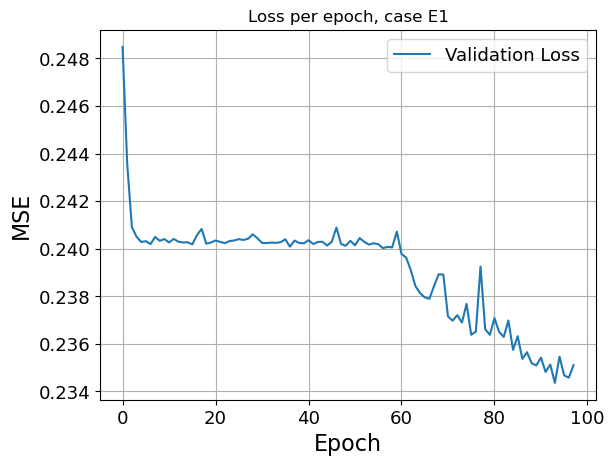

0.9680077


In [ ]:
'''INPUT PARAMETERS'''

case = 'E1'

vel_planes = [2,3,4,5]
experimental_ens_list = [1]#,2,11,12,14,15,16,17,18,19,20]    #list of experimental ensembles to run for;
                                #NOTE: can be any from 1 to 20, except 4-10
r_vals = [100]    #chosen rank for cases E1 & E2 
num_sensors = 3 #number of sensors for surface measurement. Standard is 3.
ens_start=40   #start index for first SHRED ensemble (can be 0)
ens_end=40     #last index for SHRED ensemble
lags=52     #lags for the LSTM, standard is 52  
random_sampling=True    #if True, snapshots are randomly exctracted and separated to training, validation or testing 
                        #throughout the dataset. If False, a forecast is done (not fully functional as of now)


'''RUN ENSEMBLE OF SHRED'''

sensors_list = [3]#[1,2,3,5,10,15,20,30,50,70,100,150,200,300,500,1000]
for l in range(len(sensors_list)):
    num_sensors = sensors_list[l]
    for k in range(len(vel_planes)):
        plane=vel_planes[k]
        planes = ['H395','H390', 'H375', 'H350', 'H300']
        exp_plane= planes[plane -1]
    
        for i in range(len(experimental_ens_list)):
            
            experimental_ens=experimental_ens_list[i]
            if experimental_ens > 10 or experimental_ens < 4:
                surf = utilities.get_normalized_surface_exp(case, plane, experimental_ens)

                processdata.SHRED_ensemble_exp(r_vals, num_sensors, surf, ens_start, ens_end, case, experimental_ens, lags, exp_plane=exp_plane, random_sampling=random_sampling)

# Plot and compare SHRED outputs

Now that we have SHRED results saved (the V matrix of the test images), we can calculate the full field matrix multiplication with pre-saved U and S matrices, to get reconstructed fields. We then compare this to the (uncompressed) ground truth and the compressed fields, for the surface elevation, as well as velocity fields below the surface. We plot this as a figure below:

### Compare case S2

plane  10
getting test images
test images extracted
plane  70
getting test images
test images extracted


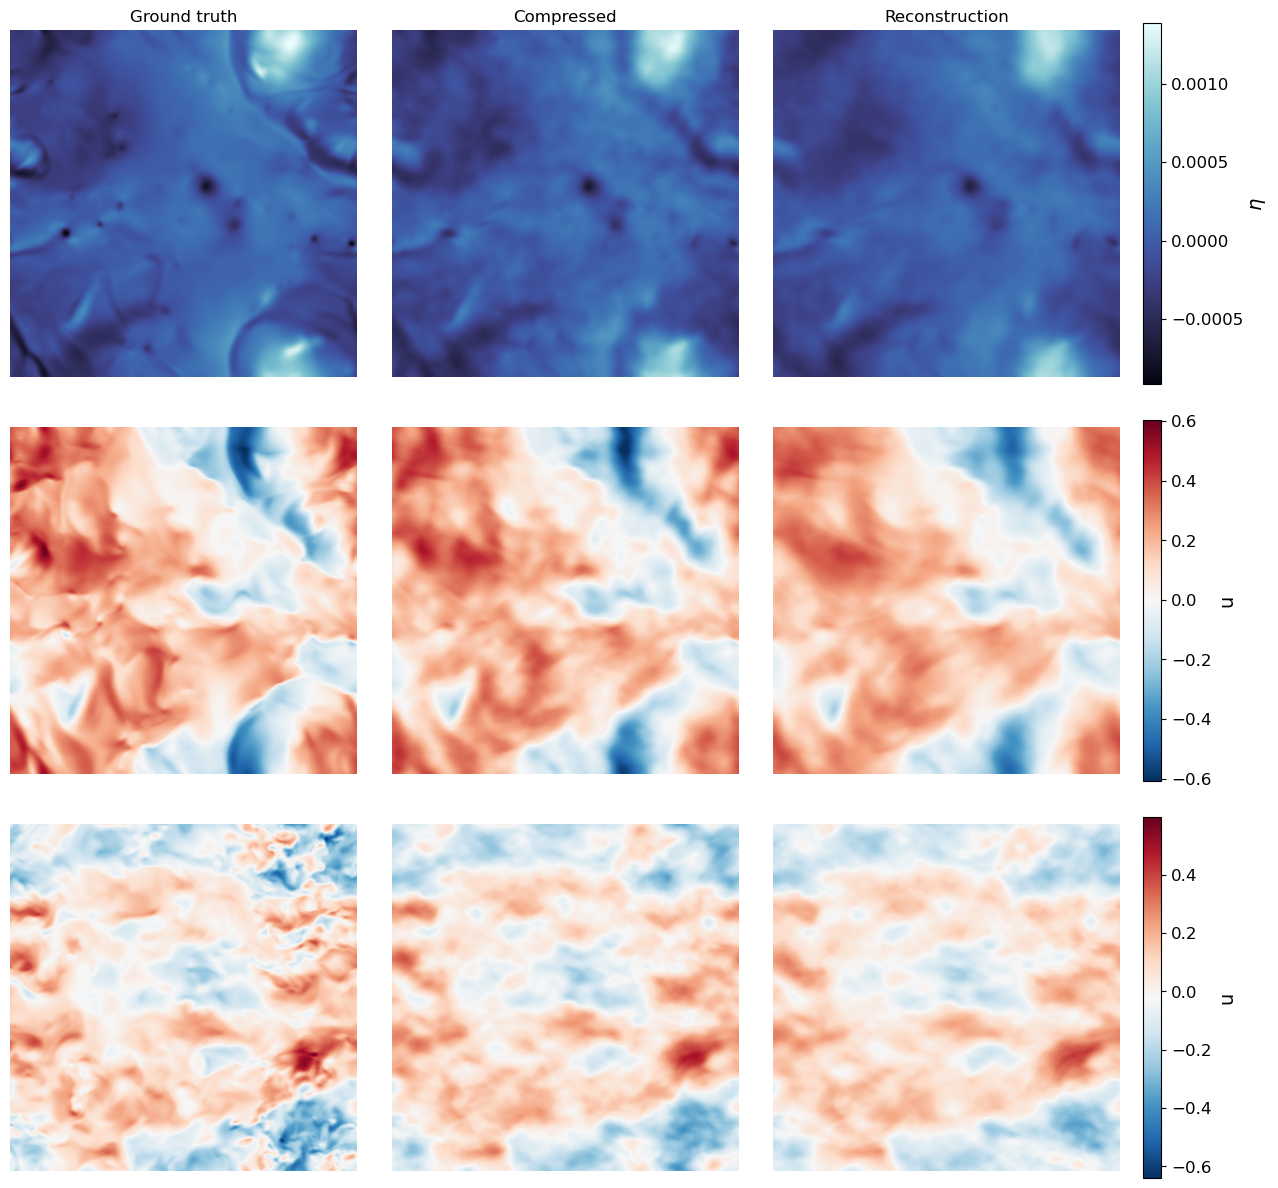

In [3]:

vel_planes = [10,70]#velocity planes to compare
rank = 250          #SVD rank used in the SHRED simulation
SHRED_ens=10        #what SHRED ensemble case to plot for
num_sensors=3       #standard is 3 sensors
test_snap_index=790 #what snapshot index in the testing data to plot
lags=52             #lags for the LSTM
forecast=False      #f the SHRED run is in forecast mode
add_surface=True    #if surface profile is to be included
full_planes=True    #if the SHRED run is coming from a full plane run, or specific planes only
case='S2'           #Simulation case


plot_results.plot_SHRED_comparison_DNS(rank, SHRED_ens, vel_planes, num_sensors, test_snap_index, 
                                        lags, forecast, add_surface, full_planes, case)

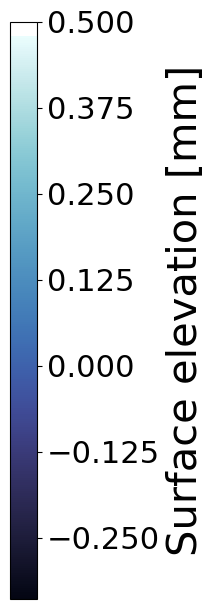

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
cmap = cmocean.cm.ice
vmax = 0.012*39.9   # replace with your actual value
vmin = -0.0085*39.9    # replace with your actual value

fig, ax = plt.subplots(figsize=(0.9, 7.5))
fig.subplots_adjust(left=0.4, right=0.7)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')

cb.set_label(r"Surface elevation [mm]", fontsize=30)
cb.set_ticks([-0.25, -0.125, 0, 0.125, 0.25, 0.375, 0.5 ])
cb.ax.tick_params(labelsize=22)

plt.savefig("eta_color_bar_S2.pdf", bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

cmap = 'RdBu_r'
vmax = 40   # replace with your actual value
vmin = -40    # replace with your actual value

fig, ax = plt.subplots(figsize=(0.6, 5))
fig.subplots_adjust(left=0.4, right=0.7)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')

cb.set_label(r"u velocity [mm/s]", fontsize=20)
cb.set_ticks([-40,-20,0,20,40])
cb.ax.tick_params(labelsize=12)

plt.savefig("u1_bar_S2.pdf", bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

cmap = 'RdBu_r'
vmax = 0.6   # replace with your actual value
vmin = -0.6    # replace with your actual value

fig, ax = plt.subplots(figsize=(0.6, 5))
fig.subplots_adjust(left=0.4, right=0.7)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')

cb.set_label(r"u fluctuation", fontsize=14)
cb.set_ticks([-0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6])
cb.ax.tick_params(labelsize=12)

plt.savefig("u1_bar_S2.pdf", bbox_inches="tight")
plt.show()

### Compare case E2

plane:  H375
load surface
getting test images
load velocity field, plane H375
test images extracted


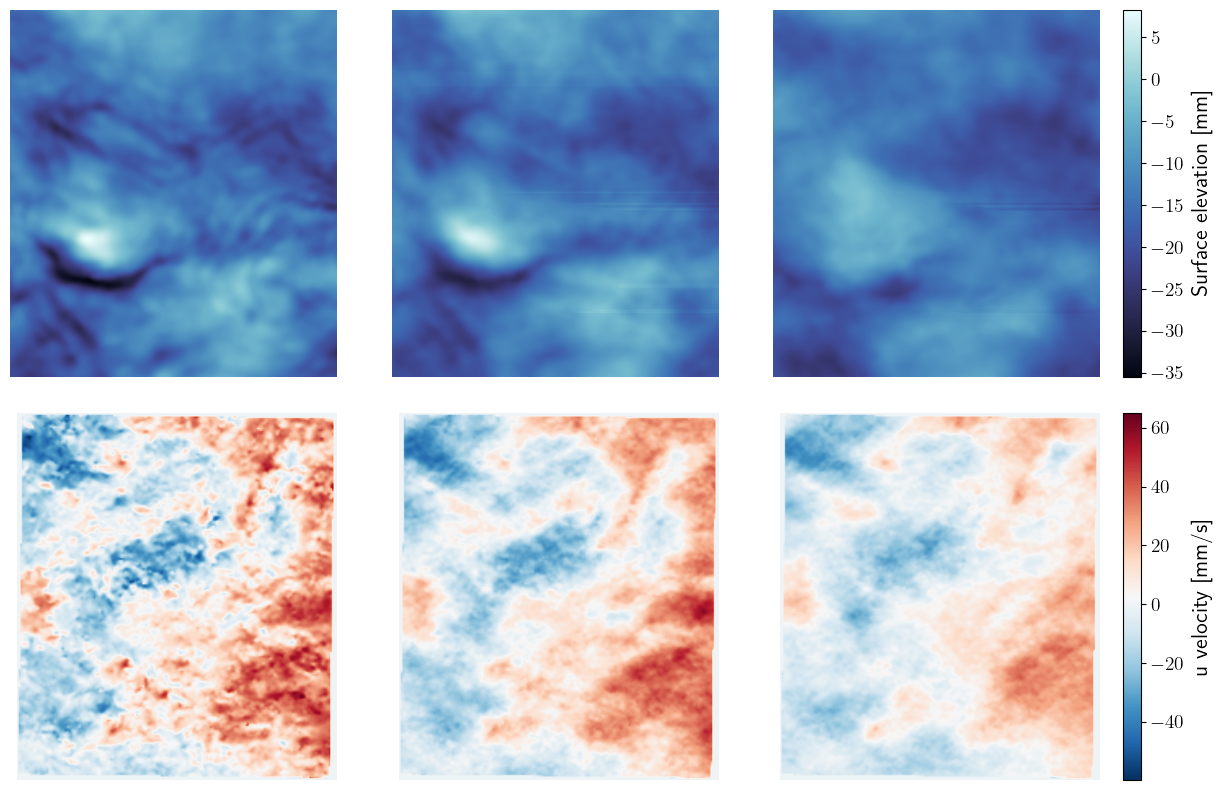

In [15]:

rank = 100              #SVD rank value used in the compression fed into SHRED
SHRED_ens=30#36            #what SHRED ensemble index to plot for
num_sensors=3
test_snap_index=63      #what snapshot index in the testing data to plot, 54
lags=52                 #lags for the LSTM, must be correct to shift the extracted test images correctly
forecast=False          
add_surface=True        #include surface in the plot
full_planes=True        #True if SHRED training comes from a set of all planes, or selected planes only  
exp_case='E2'           #E1 or E2
experimental_ens = 11#3   #list of experimental ensembles to run for; #used in paper: experimental_ens=15
                             #NOTE: can be any from 1 to 20, except 4-10
plane_list = [3]#[2]       #plane 1 doesn't exist, only planes 2 (closest to surface) to 5 (deepest)

plot_results.plot_SHRED_comparison_exp(rank, exp_case, experimental_ens, SHRED_ens, plane_list, test_snap_index,None, None, 
                              num_sensors, lags=52, forecast=False, add_surface=add_surface)


# Calculate error metrics

The following cell runs and saves error metrics (RMS, NMSE, PSDE, SSIM & PSNR) for the SHRED reconstructions of the DNS case S2 and experimental case E2. **Note:** these are NOT used to plot error metrics, only to calculate and save

#### DNS case S2

In [14]:
#NOTE: these following variables are only determined based on what parameters are used in saved SHRED runs

SHRED_ensembles = np.arange(2,5)    #list of SHRED runs to calculate for
vel_planes= np.arange(1,58)          #list of velocity planes 
r_vals = [225]                      #list of ranks
num_sensors = 3                    #number of sensors
DNS_case='S1'   
lags=52
forecast=False                  
full_planes_SHRED=True #whether to open SHRED for full planes (True), or for specific run with chosen planes (False) as given by vel_planes
                        #If True, but vel_planes is fewer planes than full length of planes, then these selected planes are calculated



#loop for iterating rank values 
for r in range(len(r_vals)):
    rank = r_vals[r]
    
    processdata.calculate_error_metrics(DNS_case, rank, vel_planes, num_sensors, SHRED_ensembles, lags, forecast, full_planes_SHRED, compare_to_compressed=True)

#NOTE for running rank dependence analysis (appendix A):
    #run with extended r_vals list of a range of ranks (their SHRED runs must be saved first)
    # full_planes=False, and only for selected vel_planes

start SHRED ensemble looping
ensemble:  0
plane:  1
calc MSE
calc SSIM
ssim_vals:  0.8728899812130362
calc PSNR
PSNR val:  30.151209234386148
calc PSD
PSD error:  0.17675919415121136
plane:  2
calc MSE
calc SSIM
ssim_vals:  0.8728931270098167
calc PSNR
PSNR val:  30.15125308181808
calc PSD
PSD error:  0.17675550287291691
plane:  3
calc MSE
calc SSIM
ssim_vals:  0.8729240835882506
calc PSNR
PSNR val:  30.151638071423196
calc PSD
PSD error:  0.17671752021838527
plane:  4
calc MSE
calc SSIM
ssim_vals:  0.8729868846326776
calc PSNR
PSNR val:  30.15237537970812
calc PSD
PSD error:  0.1766395463592075
plane:  5
calc MSE
calc SSIM
ssim_vals:  0.873080374146271
calc PSNR
PSNR val:  30.153411235740084
calc PSD
PSD error:  0.17652324790221083
plane:  6
calc MSE
calc SSIM
ssim_vals:  0.8732107454612134
calc PSNR
PSNR val:  30.154959812578195
calc PSD
PSD error:  0.17636216186912412
plane:  7
calc MSE
calc SSIM
ssim_vals:  0.8733781442109348
calc PSNR
PSNR val:  30.156954852054223
calc PSD
PSD err

KeyboardInterrupt: 

#### Experimental case E2

In [ ]:
#NOTE: these following variables are only determined based on what parameters are used in saved SHRED runs
SHRED_ensembles = [10]#[10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]
vel_planes=[2,3,4,5]
r_vals = [100]

num_sensors = 3
case='E2'
lags=52
forecast=False
full_planes_SHRED=False #whether to open SHRED for full planes (True), or for specific run with chosen planes (False) as given by vel_planes
                #If True, but vel_planes is fewer planes than full length of planes, then these selected planes are calculated

experimental_ens = [3]#[1,2,3, 11,12,13,14,15,16,17,18,19,20]

#loop for iterating rank values and sensor values
for r in range(len(r_vals)):
    rank = r_vals[r]

    processdata.calculate_error_metrics_exp(case, rank, vel_planes, num_sensors, SHRED_ensembles, experimental_ens, lags=52, forecast=False, full_planes=True)

### Calculate error metrics sensor values  (remove later)

In [ ]:
#NOTE: these following variables are only determined based on what parameters are used in saved SHRED runs

SHRED_ensembles = np.arange(107,108)    #list of SHRED runs to calculate for
vel_planes= [1,6,11,16,21,26,31,36,41,46,51,56,61,66,71,76] #np.arange(1,77)          #list of velocity planes 
r_vals = [250]                      #list of ranks
sensor_vals=[1,2,3,5,10,15, 20,30,50,70,100,150,200,300,500,1000]
num_sensors = 3                    #number of sensors
DNS_case='S2'   
lags=52
forecast=False                  
full_planes_SHRED=False #whether to open SHRED for full planes (True), or for specific run with chosen planes (False) as given by vel_planes
                        #If True, but vel_planes is fewer planes than full length of planes, then these selected planes are calculated


rank=r_vals[0]
#loop for iterating rank values 
for s in range(len(sensor_vals)):
    num_sensors = sensor_vals[s]
    
    processdata.calculate_error_metrics(DNS_case, rank, vel_planes, num_sensors, SHRED_ensembles, lags, forecast, full_planes_SHRED)

#NOTE for running rank dependence analysis (appendix A):
    #run with extended r_vals list of a range of ranks (their SHRED runs must be saved first)
    # full_planes=False, and only for selected vel_planes

In [4]:
#NOTE: these following variables are only determined based on what parameters are used in saved SHRED runs

SHRED_ensembles = np.arange(111,130)    #list of SHRED runs to calculate for
vel_planes= [1,6,11,16,21,26,31,36,41,46,51,56]#,61,66,71,76] #np.arange(1,77)          #list of velocity planes 
r_vals = [225]                      #list of ranks
sensor_vals=[150,200,300,500,1000]
num_sensors = 3                    #number of sensors
DNS_case='S1'   
lags=52
forecast=False                  
full_planes_SHRED=False #whether to open SHRED for full planes (True), or for specific run with chosen planes (False) as given by vel_planes
                        #If True, but vel_planes is fewer planes than full length of planes, then these selected planes are calculated


rank=r_vals[0]
#loop for iterating rank values 
for s in range(len(sensor_vals)):
    num_sensors = sensor_vals[s]
    
    processdata.calculate_error_metrics(DNS_case, rank, vel_planes, num_sensors, SHRED_ensembles, lags, forecast, full_planes_SHRED)

#NOTE for running rank dependence analysis (appendix A):
    #run with extended r_vals list of a range of ranks (their SHRED runs must be saved first)
    # full_planes=False, and only for selected vel_planes

start SHRED ensemble looping
ensemble:  111
plane:  1
calc MSE
calc SSIM
ssim_vals:  0.7590871745805663
calc PSNR
PSNR val:  27.399102090966238
calc PSD
PSD error:  0.2084714759480183
plane:  6
calc MSE
calc SSIM
ssim_vals:  0.7593121737360382
calc PSNR
PSNR val:  27.381578500907136
calc PSD
PSD error:  0.20821908235115327
plane:  11
calc MSE
calc SSIM
ssim_vals:  0.7604364268985058
calc PSNR
PSNR val:  27.304019843074258
calc PSD
PSD error:  0.20705576395543307
plane:  16
calc MSE
calc SSIM
ssim_vals:  0.7616990884802312
calc PSNR
PSNR val:  27.15498364970257
calc PSD
PSD error:  0.20449910389586087
plane:  21
calc MSE
calc SSIM
ssim_vals:  0.7464642044127574
calc PSNR
PSNR val:  26.8562956201292
calc PSD
PSD error:  0.2061309655892043
plane:  26
calc MSE
calc SSIM
ssim_vals:  0.7150366186425078
calc PSNR
PSNR val:  26.3641123287749
calc PSD
PSD error:  0.21637350262965518
plane:  31
calc MSE
calc SSIM
ssim_vals:  0.6947305774237919
calc PSNR
PSNR val:  25.959049200410696
calc PSD
PSD

In [7]:
#NOTE: these following variables are only determined based on what parameters are used in saved SHRED runs

SHRED_ensembles = np.arange(108,109)    #list of SHRED runs to calculate for
vel_planes= [1,6,11,16,21,26,31,36,41,46,51,56,61,66,71,76] #np.arange(1,77)          #list of velocity planes 
r_vals = [250]                      #list of ranks
sensor_vals=[1,2,3,5,10,15, 20,30,50,70,100,150,200,300,500,1000]
num_sensors = 3                    #number of sensors
DNS_case='S2'   
lags=52
forecast=False                  
full_planes_SHRED=False #whether to open SHRED for full planes (True), or for specific run with chosen planes (False) as given by vel_planes
                        #If True, but vel_planes is fewer planes than full length of planes, then these selected planes are calculated


rank=r_vals[0]
#loop for iterating rank values 
for s in range(len(sensor_vals)):
    num_sensors = sensor_vals[s]
    
    processdata.calculate_error_metrics(DNS_case, rank, vel_planes, num_sensors, SHRED_ensembles, lags, forecast, full_planes_SHRED)

#NOTE for running rank dependence analysis (appendix A):
    #run with extended r_vals list of a range of ranks (their SHRED runs must be saved first)
    # full_planes=False, and only for selected vel_planes

start SHRED ensemble looping
ensemble:  108
plane:  1
calc MSE
calc SSIM
ssim_vals:  0.6951753799611521
calc PSNR
PSNR val:  26.325638327801975
calc PSD
PSD error:  0.22052504153463331
plane:  6
calc MSE
calc SSIM
ssim_vals:  0.6951029380854009
calc PSNR
PSNR val:  26.289572107934756
calc PSD
PSD error:  0.21999335599220704
plane:  11
calc MSE
calc SSIM
ssim_vals:  0.6965181698457336
calc PSNR
PSNR val:  26.224420781494814
calc PSD
PSD error:  0.21739495304600948
plane:  16
calc MSE
calc SSIM
ssim_vals:  0.6968191929205043
calc PSNR
PSNR val:  26.261490587197805
calc PSD
PSD error:  0.21322877826638267
plane:  21
calc MSE
calc SSIM
ssim_vals:  0.6682185395047704
calc PSNR
PSNR val:  25.95641669356829
calc PSD
PSD error:  0.2150154433868445
plane:  26
calc MSE
calc SSIM
ssim_vals:  0.6359344045340668
calc PSNR
PSNR val:  25.380501061345587
calc PSD
PSD error:  0.22410828803180452
plane:  31
calc MSE
calc SSIM
ssim_vals:  0.6179907861007927
calc PSNR
PSNR val:  25.02315521839003
calc PSD

In [8]:
#NOTE: these following variables are only determined based on what parameters are used in saved SHRED runs

SHRED_ensembles = np.arange(109,110)    #list of SHRED runs to calculate for
vel_planes= [1,6,11,16,21,26,31,36,41,46,51,56,61,66,71,76] #np.arange(1,77)          #list of velocity planes 
r_vals = [250]                      #list of ranks
sensor_vals=[1,2,3,5,10,15, 20,30,50,70,100,150,200,300,500,1000]
num_sensors = 3                    #number of sensors
DNS_case='S2'   
lags=52
forecast=False                  
full_planes_SHRED=False #whether to open SHRED for full planes (True), or for specific run with chosen planes (False) as given by vel_planes
                        #If True, but vel_planes is fewer planes than full length of planes, then these selected planes are calculated


rank=r_vals[0]
#loop for iterating rank values 
for s in range(len(sensor_vals)):
    num_sensors = sensor_vals[s]
    
    processdata.calculate_error_metrics(DNS_case, rank, vel_planes, num_sensors, SHRED_ensembles, lags, forecast, full_planes_SHRED)

#NOTE for running rank dependence analysis (appendix A):
    #run with extended r_vals list of a range of ranks (their SHRED runs must be saved first)
    # full_planes=False, and only for selected vel_planes

start SHRED ensemble looping
ensemble:  109
plane:  1
calc MSE
calc SSIM
ssim_vals:  0.6765291285905173
calc PSNR
PSNR val:  25.876946494490998
calc PSD
PSD error:  0.24367413682176414
plane:  6
calc MSE
calc SSIM
ssim_vals:  0.6763702490651468
calc PSNR
PSNR val:  25.837875485733758
calc PSD
PSD error:  0.24319479209467587
plane:  11
calc MSE
calc SSIM
ssim_vals:  0.677445976674409
calc PSNR
PSNR val:  25.754693348431246
calc PSD
PSD error:  0.24071472306290892
plane:  16
calc MSE
calc SSIM
ssim_vals:  0.6770202410566545
calc PSNR
PSNR val:  25.76401827406359
calc PSD
PSD error:  0.23649955643929527
plane:  21
calc MSE
calc SSIM
ssim_vals:  0.6474799181647337
calc PSNR
PSNR val:  25.472234050665957
calc PSD
PSD error:  0.23754947111795272
plane:  26
calc MSE
calc SSIM
ssim_vals:  0.6153826674683766
calc PSNR
PSNR val:  24.944389497428823
calc PSD
PSD error:  0.2464454148528189
plane:  31
calc MSE
calc SSIM
ssim_vals:  0.5991503837880399
calc PSNR
PSNR val:  24.645668269990438
calc PSD

In [ ]:
#NOTE: these following variables are only determined based on what parameters are used in saved SHRED runs

SHRED_ensembles = np.arange(13,26)    #list of SHRED runs to calculate for
vel_planes= np.arange(1,77)#[1,6,11,16,21,26,31,36,41,46,51,56,61,66,71,76] #np.arange(1,77)          #list of velocity planes 
r_vals = [250]                      #list of ranks
sensor_vals=[3]#[20,30,50,70,100,150,200,300,500,1000]
num_sensors = 3                    #number of sensors
DNS_case='S2'   
lags=52
forecast=False                  
full_planes_SHRED=True #whether to open SHRED for full planes (True), or for specific run with chosen planes (False) as given by vel_planes
                        #If True, but vel_planes is fewer planes than full length of planes, then these selected planes are calculated


rank=r_vals[0]
#loop for iterating rank values 
for s in range(len(sensor_vals)):
    num_sensors = sensor_vals[s]
    
    processdata.calculate_error_metrics(DNS_case, rank, vel_planes, num_sensors, SHRED_ensembles, lags, forecast, full_planes_SHRED, compare_to_compressed=True)

#NOTE for running rank dependence analysis (appendix A):
    #run with extended r_vals list of a range of ranks (their SHRED runs must be saved first)
    # full_planes=False, and only for selected vel_planes

start SHRED ensemble looping
ensemble:  13
plane:  1
calc MSE
calc SSIM
ssim_vals:  0.8377520147182236
calc PSNR
PSNR val:  29.100301335068245
calc PSD
PSD error:  0.18484134361010016
plane:  2
calc MSE
calc SSIM
ssim_vals:  0.8377614777924539
calc PSNR
PSNR val:  29.100512629146834
calc PSD
PSD error:  0.18483407274609143
plane:  3
calc MSE
calc SSIM
ssim_vals:  0.8378528071574076
calc PSNR
PSNR val:  29.10232064872126
calc PSD
PSD error:  0.18476257499961002
plane:  4
calc MSE
calc SSIM
ssim_vals:  0.8380368222767626
calc PSNR
PSNR val:  29.105936622496692
calc PSD
PSD error:  0.18461880675130074
plane:  5
calc MSE
calc SSIM
ssim_vals:  0.8383057082942053
calc PSNR
PSNR val:  29.11114523211631
calc PSD
PSD error:  0.18440720186171292
plane:  6
calc MSE
calc SSIM
ssim_vals:  0.8386669610531242
calc PSNR
PSNR val:  29.118359923158923
calc PSD
PSD error:  0.18412371968133312
plane:  7
calc MSE
calc SSIM
ssim_vals:  0.8391534939380696
calc PSNR
PSNR val:  29.128368044612788
calc PSD
PSD 

In [3]:
#NOTE: these following variables are only determined based on what parameters are used in saved SHRED runs
vel_planes=[2,3,4,5]
r_vals = [100]
SHRED_ensembles = np.arange(10,40)#np.arange(101,121) 
sensor_vals = [3]#[1,2,3,5,10,15,20,30,50,70,100,150,200,300,500,1000]

case='E1'
lags=52
forecast=False
full_planes_SHRED=True #whether to open SHRED for full planes (True), or for specific run with chosen planes (False) as given by vel_planes
                #If True, but vel_planes is fewer planes than full length of planes, then these selected planes are calculated

experimental_ens = [13,14,15,16,17,18,19,20]#[1,2,3, 11,12,13,14,15,16,17,18,19,20]
rank=r_vals[0]
#loop for iterating rank values and sensor values
for s in range(len(sensor_vals)):
    num_sensors = sensor_vals[s]

    processdata.calculate_error_metrics_exp(case, rank, vel_planes, num_sensors, SHRED_ensembles, experimental_ens, lags=52, forecast=False, full_planes=True, compare_to_compressed=True)

start ensemble looping
ensemble:  10
plane:  2
Plane:  H390
load velocity field, plane H390
calc MSE
calc SSIM
ssim_vals:  0.8254672002917876
calc PSNR
PSNR val:  27.24531741647075
calc PSD
PSD val:  0.12124474845173482
plane:  3
Plane:  H375
load velocity field, plane H375
calc MSE
calc SSIM
ssim_vals:  0.8496870393611329
calc PSNR
PSNR val:  28.23536648698947
calc PSD
PSD val:  0.13756640355129332
plane:  4
Plane:  H350
load velocity field, plane H350
calc MSE
calc SSIM
ssim_vals:  0.809727739676338
calc PSNR
PSNR val:  28.714192034900893
calc PSD
PSD val:  0.11796352269350609
plane:  5
Plane:  H300
load velocity field, plane H300
calc MSE
calc SSIM
ssim_vals:  0.7449024940824807
calc PSNR
PSNR val:  25.72202731013052
calc PSD
PSD val:  0.19781768743409603
saved successfully!
ensemble:  11
plane:  2
Plane:  H390
load velocity field, plane H390
calc MSE
calc SSIM
ssim_vals:  0.8115442076300596
calc PSNR
PSNR val:  27.63684787810577
calc PSD
PSD val:  0.16786898061362
plane:  3
Plane: 

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'e:\Users\krissmoe\Documents\SHRED-turbulence-sensing\output\SHRED\Teetank_SHRED_new_ens14_P25_H390_r100_3sensors_ens10.mat', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [3]:
#NOTE: these following variables are only determined based on what parameters are used in saved SHRED runs
vel_planes=[2,3,4,5]
r_vals = [100]
SHRED_ensembles = np.arange(3,40)#np.arange(101,121) 
sensor_vals = [3]#[1,2,3,5,10,15,20,30,50,70,100,150,200,300,500,1000]

case='E1'
lags=52
forecast=False
full_planes_SHRED=True #whether to open SHRED for full planes (True), or for specific run with chosen planes (False) as given by vel_planes
                #If True, but vel_planes is fewer planes than full length of planes, then these selected planes are calculated

experimental_ens = [1,2,11,12,14]#,2,11,12,14,15,16,17,18,19,20]#[1,2,3, 11,12,13,14,15,16,17,18,19,20]
rank=r_vals[0]
#loop for iterating rank values and sensor values
for s in range(len(sensor_vals)):
    num_sensors = sensor_vals[s]

    processdata.calculate_error_metrics_exp(case, rank, vel_planes, num_sensors, SHRED_ensembles, experimental_ens, lags=52, forecast=False, full_planes=True, compare_to_compressed=True)

start ensemble looping
ensemble:  3
plane:  2
Plane:  H390
TEST:  P25


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'e:\Users\krissmoe\Documents\SHRED-turbulence-sensing\output\SHRED\Teetank_SHRED_new_ens1_P25_H390_r100_3sensors_ens3.mat', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [13]:
#NOTE: these following variables are only determined based on what parameters are used in saved SHRED runs
vel_planes=[2,3,4,5]
r_vals = [100]
SHRED_ensembles = np.arange(10,40)#np.arange(101,121) 
sensor_vals = [3]#[1,2,3,5,10,15,20,30,50,70,100,150,200,300,500,1000]

case='E2'
lags=52
forecast=False
full_planes_SHRED=True #whether to open SHRED for full planes (True), or for specific run with chosen planes (False) as given by vel_planes
                #If True, but vel_planes is fewer planes than full length of planes, then these selected planes are calculated

experimental_ens = [18]#,2,11,12,14,15,16,17,18,19,20]#[1,2,3, 11,12,13,14,15,16,17,18,19,20]
rank=r_vals[0]
#loop for iterating rank values and sensor values
for s in range(len(sensor_vals)):
    num_sensors = sensor_vals[s]

    processdata.calculate_error_metrics_exp(case, rank, vel_planes, num_sensors, SHRED_ensembles, experimental_ens, lags=52, forecast=False, full_planes=True, compare_to_compressed=True)

start ensemble looping
ensemble:  10
plane:  2
Plane:  H390
TEST:  P50
load velocity field, plane H390
calc MSE
calc SSIM
ssim_vals:  0.09491154948786981
calc PSNR
PSNR val:  12.97985439413861
calc PSD
PSD val:  0.7311313988781717
plane:  3
Plane:  H375
TEST:  P50
load velocity field, plane H375
calc MSE
calc SSIM
ssim_vals:  0.6312567759240292
calc PSNR
PSNR val:  22.607392558696212
calc PSD
PSD val:  0.17114673637162153
plane:  4
Plane:  H350
TEST:  P50
load velocity field, plane H350
calc MSE
calc SSIM
ssim_vals:  0.7290150076686925
calc PSNR
PSNR val:  24.60936846337111
calc PSD
PSD val:  0.11721540618091204
plane:  5
Plane:  H300
TEST:  P50
load velocity field, plane H300
calc MSE
calc SSIM
ssim_vals:  0.15107609550364387
calc PSNR
PSNR val:  14.756455873506823
calc PSD
PSD val:  0.8402589136207389
saved successfully!
ensemble:  11
plane:  2
Plane:  H390
TEST:  P50
load velocity field, plane H390
calc MSE
calc SSIM
ssim_vals:  0.12830516461585845
calc PSNR
PSNR val:  13.1592601864

KeyboardInterrupt: 

In [ ]:
#NOTE: these following variables are only determined based on what parameters are used in saved SHRED runs
vel_planes=[2,3,4,5]
r_vals = [100]
SHRED_ensembles = np.arange(20,30)#np.arange(101,121) 
sensor_vals = [3]#[1,2,3,5,10,15,20,30,50,70,100,150,200,300,500,1000]
num_sensors = 300
case='E2'
lags=52
forecast=False
full_planes_SHRED=False #whether to open SHRED for full planes (True), or for specific run with chosen planes (False) as given by vel_planes
                #If True, but vel_planes is fewer planes than full length of planes, then these selected planes are calculated

experimental_ens = [13]#[1,2,3, 11,12,13,14,15,16,17,18,19,20]
rank=r_vals[0]
#loop for iterating rank values and sensor values
for s in range(len(sensor_vals)):
    num_sensors = sensor_vals[s]

    processdata.calculate_error_metrics_exp(case, rank, vel_planes, num_sensors, SHRED_ensembles, experimental_ens, lags=52, forecast=False, full_planes=True, compare_to_compressed=True)

In [4]:
#NOTE: these following variables are only determined based on what parameters are used in saved SHRED runs
vel_planes=[2,3,4,5]
r_vals = [100]
SHRED_ensembles = np.arange(10,40)#np.arange(101,121) 
sensor_vals = [3]#[1,2,3,5,10,15,20,30,50,70,100,150,200,300,500,1000]

case='E2'
lags=52
forecast=False
full_planes_SHRED=True #whether to open SHRED for full planes (True), or for specific run with chosen planes (False) as given by vel_planes
                #If True, but vel_planes is fewer planes than full length of planes, then these selected planes are calculated

experimental_ens = [1]#[1,2,3, 11,12,13,14,15,16,17,18,19,20]
rank=r_vals[0]
#loop for iterating rank values and sensor values
for s in range(len(sensor_vals)):
    num_sensors = sensor_vals[s]

    processdata.calculate_error_metrics_exp(case, rank, vel_planes, num_sensors, SHRED_ensembles, experimental_ens, lags=52, forecast=False, full_planes=True, compare_to_compressed=False)

start ensemble looping
ensemble:  10
plane:  2
Plane:  H390
TEST:  P50
load velocity field, plane H390
calc MSE
calc SSIM
ssim_vals:  0.10798270440037962
calc PSNR
PSNR val:  15.115088958096045
calc PSD
PSD val:  0.8477854028904761
plane:  3
Plane:  H375
TEST:  P50
load velocity field, plane H375
calc MSE
calc SSIM
ssim_vals:  0.4516282348452161
calc PSNR
PSNR val:  23.168719625346498
calc PSD
PSD val:  0.3365548106563227
plane:  4
Plane:  H350
TEST:  P50
load velocity field, plane H350
calc MSE
calc SSIM
ssim_vals:  0.42883216694731574
calc PSNR
PSNR val:  22.3902088508119
calc PSD
PSD val:  0.2353531213912815
plane:  5
Plane:  H300
TEST:  P50
load velocity field, plane H300
calc MSE
calc SSIM
ssim_vals:  0.17642495977869
calc PSNR
PSNR val:  18.00701300152877
calc PSD
PSD val:  0.6137237266914994
saved successfully!
ensemble:  11
plane:  2
Plane:  H390
TEST:  P50
load velocity field, plane H390
calc MSE
calc SSIM
ssim_vals:  0.4129515190941577
calc PSNR
PSNR val:  22.16375326132858
c

KeyboardInterrupt: 

In [ ]:
#NOTE: these following variables are only determined based on what parameters are used in saved SHRED runs
vel_planes=[2,3,4,5]
r_vals = [100]
SHRED_ensembles = np.arange(10,40)#np.arange(101,121) 
sensor_vals = [3]#[1,2,3,5,10,15,20,30,50,70,100,150,200,300,500,1000]

case='E2'
lags=52
forecast=False
full_planes_SHRED=True #whether to open SHRED for full planes (True), or for specific run with chosen planes (False) as given by vel_planes
                #If True, but vel_planes is fewer planes than full length of planes, then these selected planes are calculated

experimental_ens = [3]#[1,2,3, 11,12,13,14,15,16,17,18,19,20]
rank=r_vals[0]
#loop for iterating rank values and sensor values
for s in range(len(sensor_vals)):
    num_sensors = sensor_vals[s]

    processdata.calculate_error_metrics_exp(case, rank, vel_planes, num_sensors, SHRED_ensembles, experimental_ens, lags=52, forecast=False, full_planes=True, compare_to_compressed=True)

Before running ensemble-averaged depth dependent error metric profiles, we also need to calculate the true RMS profiles of all four cases and save them. This is because it is used in the RMS plots. To do this, we can run this cell:

In [ ]:
dimT = 10900
DNS_case='S1'
vel_planes = np.arange(1,58)
rms_z_true = processdata.calc_RMS_profile_true(DNS_case, vel_planes, dimT)

dimT = 12500
DNS_case='S2'
vel_planes = np.arange(1,58)
rms_z_true = processdata.calc_RMS_profile_true(DNS_case, vel_planes, dimT)

dimT = 900
DNS_case='E1'
vel_planes = np.arange(2,6)
rms_z_true = processdata.calc_RMS_profile_true_exp(vel_planes, dimT, case, num_experimental_ensembles=1)

dimT = 900
DNS_case='E2'
vel_planes = np.arange(2,6)
rms_z_true = processdata.calc_RMS_profile_true_exp(vel_planes, dimT, case, num_experimental_ensembles=1)



# Plot ensemble-averaged depth-dependent error metric profiles

In the following cell, we plot the depth-dependent error metrics corresponding to Fig. 9 in the paper. The vertical profiles of depth-dependent metrics such as Normalized Mean Squared Error (NMSE), Power Spectral Density Error (PSDE), Structural Similarity Index Measure (SSIM) and Peak Signal-to-Noise Ratio (PSNR) are plotted. These are averaged across a range of SHRED ensemble runs. 

L_INT:  1.0004362409715295
L_INT:  1.0762489330420228
  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
RE1000 |   79.017 |   78.343 |   76.903 |   74.8
  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
RE2500 |   78.697 |   77.626 |   75.803 |   74.5
  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
   P25 |   75.896 |   75.338 |   73.670 |   73.7
  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
   P50 |   72.606 |   71.339 |   69.648 |   69.6


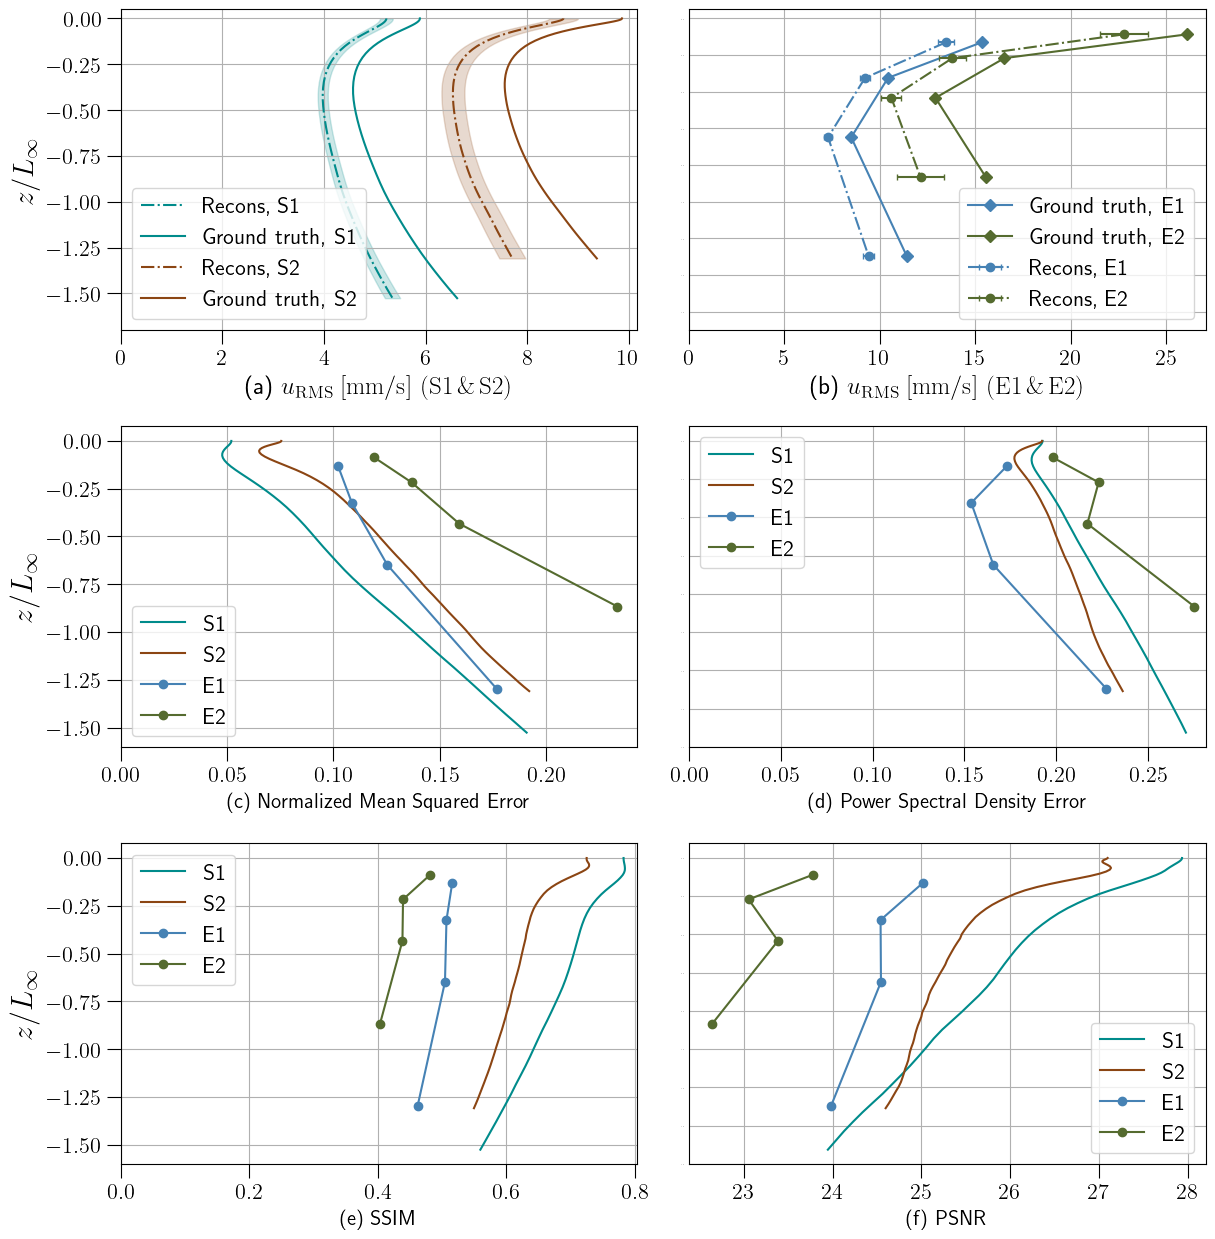

In [ ]:

DNS_cases=['S1','S2']
exp_cases = ['E1', 'E2']


vel_planes_S1=np.arange(1,58)
vel_planes_S2=np.arange(1,77)
vel_planes_S2_POD = [1,6,11,16,21,26,31,36,41,46,51,56,61,66,71,76]
vel_planes_exp = [2,3,4,5]
full_planes_exp = True
full_planes=True
full_planes_error_basis=False
pod = False

exp_ensembles_E1 = [1,2,3, 11,12,13,14,15,16,17,18,19,20]
exp_ensembles_E2 = [1,2,3, 11,12,13,14,15,16,17,18,19,20]


SHRED_ensembles_S1= np.arange(0,26)
SHRED_ensembles_S2= np.arange(0,26)
SHRED_ensembles_S2_POD = np.arange(200,201)
SHRED_ensembles_E1 = np.arange(10,40)
SHRED_ensembles_E2 = np.arange(10,40)

num_sensors=3
ranks = [225,250, 100,100]
forecast=False
colors=['darkcyan', 'saddlebrown', 'steelblue', 'darkolivegreen']
z_norm='int' # what length scale to normalize depth with : 'taylor', 'mixed', 'int' or None


plot_results.plot_depth_dependent_error_metrics(DNS_cases, exp_cases, ranks, colors, vel_planes_S1, vel_planes_S2, vel_planes_S2_POD, vel_planes_exp, num_sensors, 
                                                   SHRED_ensembles_S1,SHRED_ensembles_S2, SHRED_ensembles_S2_POD, SHRED_ensembles_E1, SHRED_ensembles_E2, exp_ensembles_E1, 
                                                   exp_ensembles_E2, forecast=False,full_planes=True, full_planes_exp=full_planes_exp, z_norm=z_norm, pod=pod)

# COMPRESSED VERSION

L_INT:  1.0762489330420228
L_INT:  1.0762489330420228
  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
RE2500 |   82.116 |   81.728 |   80.773 |   80.0
  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
RE2500 |   78.697 |   77.626 |   75.803 |   74.5
  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
   P50 |   56.724 |   54.512 |   51.881 |   51.9
  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
   P50 |   72.353 |   71.183 |   69.501 |   69.5


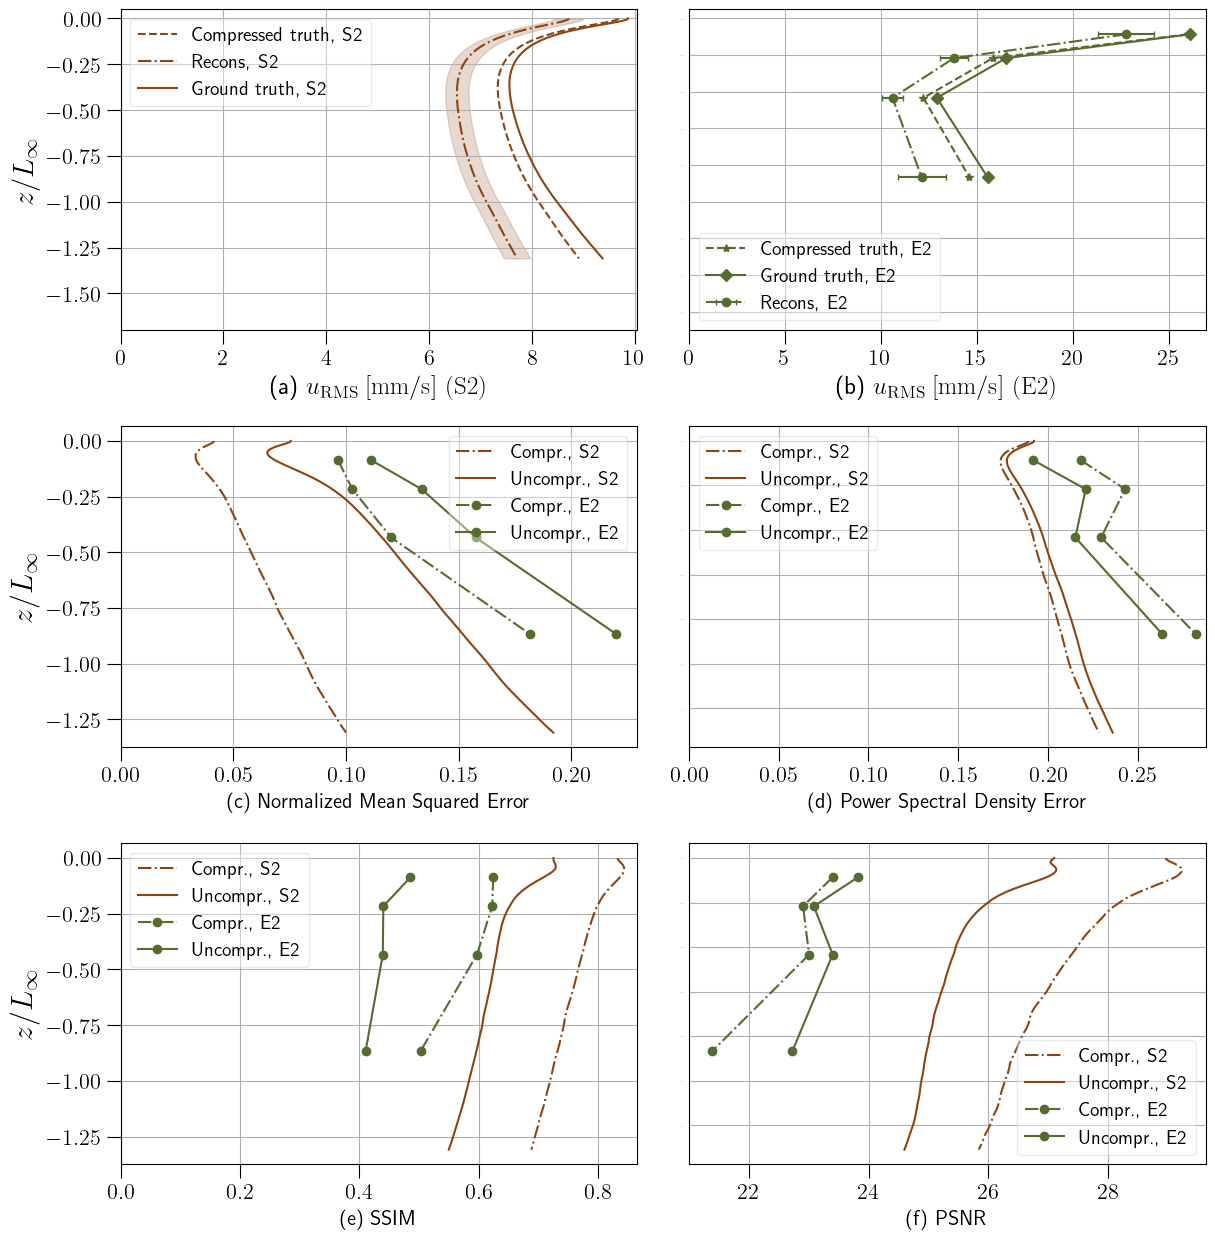

In [2]:

DNS_cases=['S2','S2']
exp_cases = ['E2', 'E2']


vel_planes_S1=np.arange(1,58)
vel_planes_S2=np.arange(1,77)

#vel_planes_S2=vel_planes_S1
vel_planes_S2_POD = [1,6,11,16,21,26,31,36,41,46,51,56,61,66,71,76]
vel_planes_exp = [2,3,4,5]
full_planes_exp = True
full_planes=True
full_planes_error_basis=False
pod = False

exp_ensembles_E2_c =[1,2,3, 11,12,13,14,15,16,17,18,19,20]
exp_ensembles_E2 = [1,2,3, 11,12,13,14,15,16,17,18,19,20]


SHRED_ensembles_S2_c= np.arange(10,21)#np.arange(0,2)#np.arange(10,13)
SHRED_ensembles_S2= np.arange(0,26)
SHRED_ensembles_S2_POD = np.arange(200,201)
SHRED_ensembles_E2_c = np.arange(10,40)
SHRED_ensembles_E2 = np.arange(10,40)

num_sensors=3
ranks = [250,250, 100,100]
forecast=False
colors=['darkcyan', 'saddlebrown', 'steelblue', 'darkolivegreen']
z_norm='int' # what length scale to normalize depth with : 'taylor', 'mixed', 'int' or None


plot_results.plot_depth_dependent_error_metrics_compressed(DNS_cases, exp_cases, ranks, colors, vel_planes_S2, vel_planes_S2, vel_planes_S2_POD, vel_planes_exp, num_sensors, 
                                                   SHRED_ensembles_S2_c,SHRED_ensembles_S2, SHRED_ensembles_S2_POD, SHRED_ensembles_E2_c, SHRED_ensembles_E2, exp_ensembles_E2_c, 
                                                   exp_ensembles_E2, forecast=False,full_planes=True, full_planes_exp=full_planes_exp, z_norm=z_norm, pod=pod, compare_with_compressed=True)

In [ ]:
DNS_case='RE2500'
zz = utilities.get_zz_DNS(DNS_case)
Z_INT = utilities.get_normalized_z(zz, 'int', DNS_case)

for i, val in enumerate(Z_INT, start=0):
    print(f"{i:2d} | {val}")

## Calculate instantaneous vertical RMS profiles (Fig. 8)

First, we calculate every the vertical profile of the planar RMS velocity for all test snapshots given a SHRED ensemble case and other parameters. Then we plot, using a plotter. 

In [ ]:
DNS_case='S2'
SHRED_ens = 0
rank = 250
num_sensors =3


processdata.calculate_instantaneous_rms_profile(DNS_case, SHRED_ens, rank, num_sensors)

In [ ]:
exp_case='E2'
experimental_ens=3
SHRED_ens = 3
rank=100
num_sensors=3


rms_gt, rms_recons = processdata.calculate_instantaneous_rms_profile_exp(exp_case, experimental_ens, SHRED_ens, rank, num_sensors)

#### Plot instantaneous vertical RMS profiles 

L_INT:  1.0004362409715295
L_INT:  1.0762489330420228
0
1
2


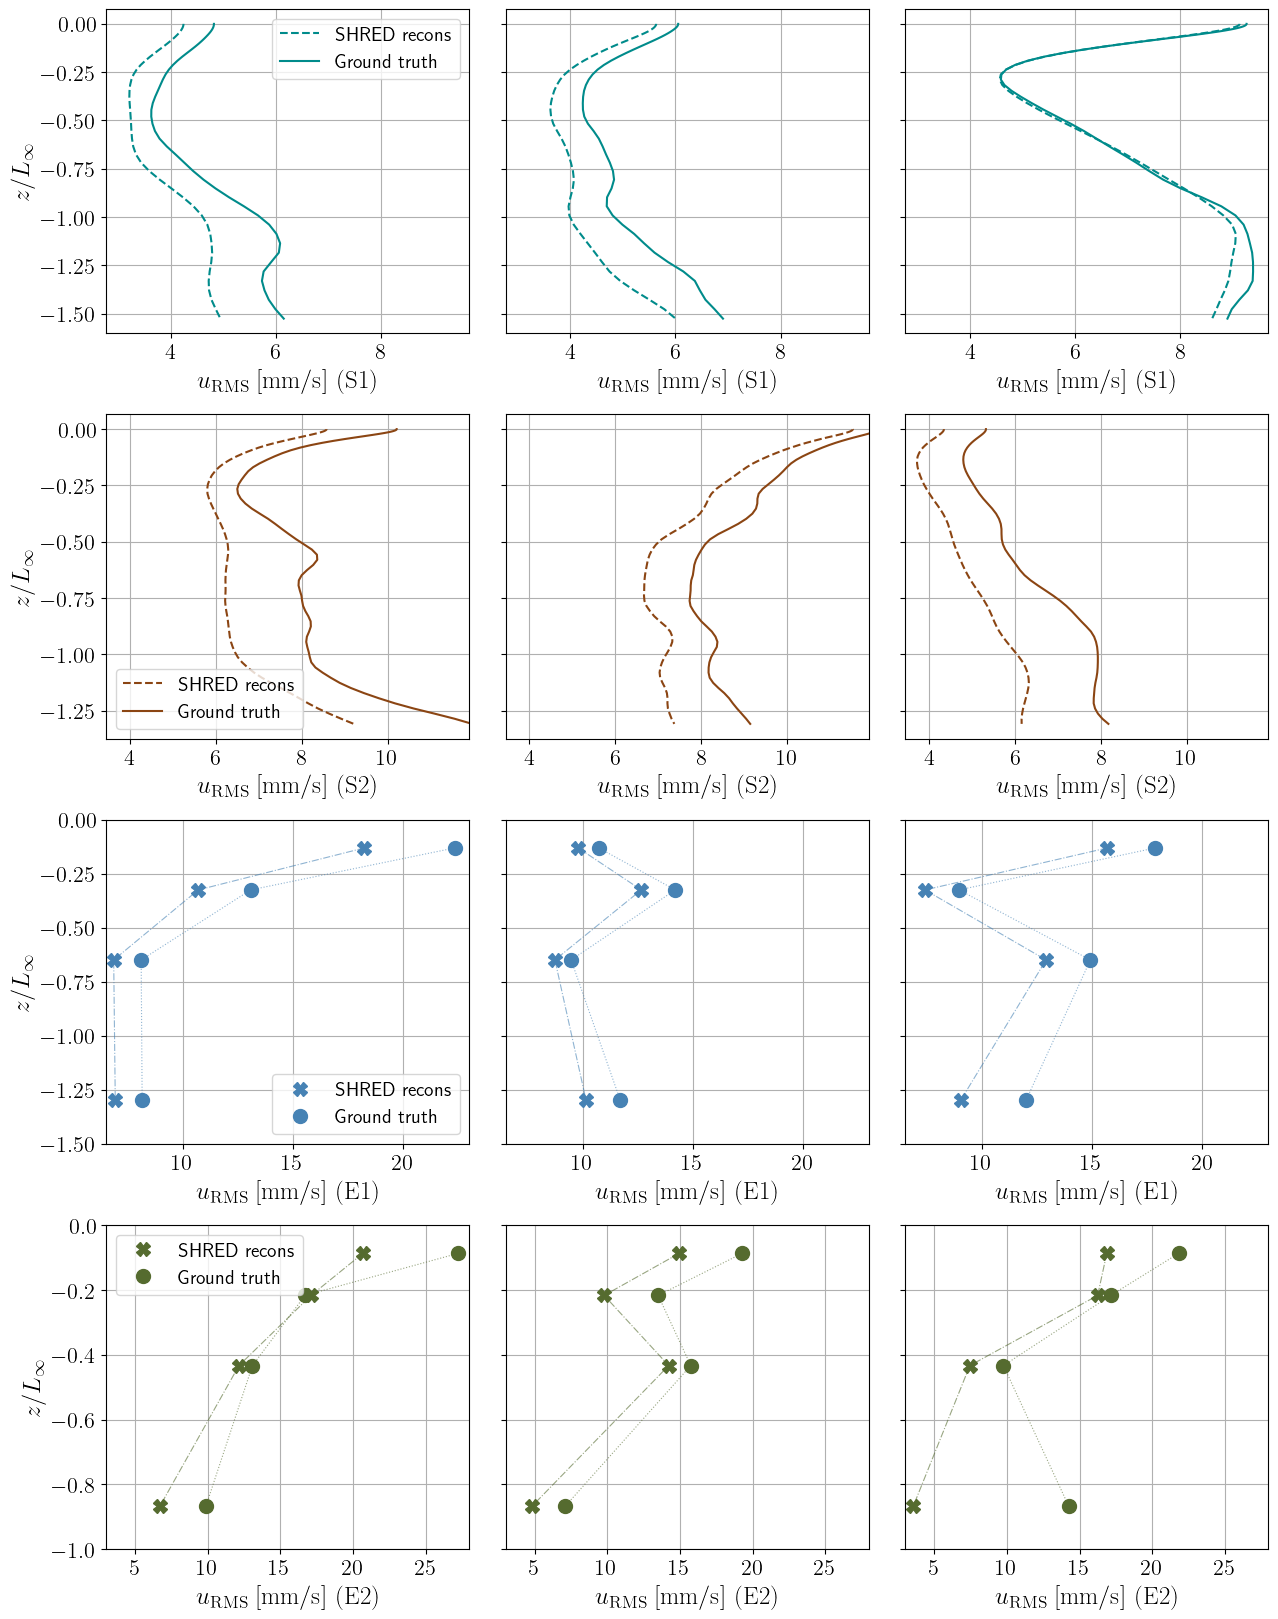

In [2]:

SHRED_ens_DNS = 0
ranks = [225,250, 100,100]
num_sensors =3
snap_indices_DNS = [20,150,300]
colors = ['peru', 'forestgreen', 'midnightblue']
colors=['darkcyan', 'saddlebrown', 'steelblue', 'darkolivegreen']
experimental_ens=3
SHRED_ens_exp=3
snap_indices_exp = [5,25,50]
labels= [['Ground truth', 'SHRED recons'], ['Ground truth 2', 'recons 2'], ['Ground truth 3', 'recons 3']]
plot_results.plot_instantaneous_RMS(experimental_ens, SHRED_ens_DNS, SHRED_ens_exp, snap_indices_DNS, snap_indices_exp, ranks, num_sensors, colors, labels, z_norm='int')

# Calculate and plot planar RMS time series of ground truth vs reconstruction

For a visual representation of the temporal performance of SHRED, we plot the time series of chosen error metrics for test snapshots. Options are the u RMS (the plotter function will plot both ground truth, as black solid line, and reconstruction, as blue dashed line), MSE, PSD error, SSIM or PSNR. Fig. 10 in paper, i.e. the u RMS of ground truth and reconstruction for all cases, for a representative SHRED run, and planes at around $0.14L_{\infty}-0.20L_{\infty}$ is reproduced below.

In [ ]:
ranks = [225, 250, 100, 100]
vel_planes = [20,20,2,2]
SHRED_ensembles = [14, 14,33,33]          #SHRED ensemle index for each of the cases S1, S2, E1, E2
experimental_ensembles = [13, 13]   #experimental ensemble to choose. Pick only one!
metric='rms'                   #'rms', 'mse', 'psd', 'ssim' or 'psnr'

plot_results.plot_time_series_error_metrics(ranks, vel_planes, SHRED_ensembles, experimental_ensembles,metric)

#### Deeper plane analysis:

In [ ]:

ranks = [225, 250, 100, 100]
vel_planes = [40,50,5,5]
SHRED_ensembles = [14, 14,33,33]          #SHRED ensemle index for each of the cases S1, S2, E1, E2
experimental_ensembles = [13, 13]   #experimental ensemble to choose. Pick only one!
metric='rms'                   #'rms', 'mse', 'psd', 'ssim' or 'psnr'

plot_results.plot_time_series_error_metrics(ranks, vel_planes, SHRED_ensembles, experimental_ensembles,metric)

# Plot PSD spectra for ground truth vs reconstruction 

In the following cell, we plot and replicate Fig. 11, of PSD spectra of ground truth and SHRED reconstructions for all cases, at a specified depth. 

In [ ]:
vel_planes = [40,50,5,5]
ranks = [225, 250, 100, 100]
SHRED_ensembles=[7,7, 33, 33]
experimental_ensembles = [13, 13]
ranks = [225, 250, 100, 100]
num_sensors=3

plot_results.plot_psd_all_cases(vel_planes, SHRED_ensembles, experimental_ensembles, ranks, num_sensors)

##### Spectra near-surface

In [ ]:
vel_planes = [20,20,2,2]
ranks = [225, 250, 100, 100]
SHRED_ensembles=[7,7, 33, 33]
experimental_ensembles = [13, 13]
ranks = [225, 250, 100, 100]
num_sensors=3

plot_results.plot_psd_all_cases(vel_planes, SHRED_ensembles, experimental_ensembles, ranks, num_sensors)

# Plot PSD spectra dependence on rank values

To illustrate the loss from SVD compression versus SHRED reconstruction, we plot the PSD spectra dependence on rank values.

In [ ]:


DNS=True
case = 'S2'
vel_planes = [1,6,11,16,21,26,31,36,41,46,51,56,61,66,71,76]
plane_index = 5 #plane 26
num_sensors = 3
SHRED_ens = 9
r_vals = np.array([25,125,250,325,400, 450])
experimental_ens=None
split_rank = 325
plot_results.plot_psd_rank_comparison_with_SHRED(r_vals, case, DNS, vel_planes, plane_index, num_sensors, SHRED_ens, experimental_ens, split_rank)

In [ ]:
DNS=False
case = 'E1'
vel_planes = [2,3,4,5]
plane_index = 4 
num_sensors = 3
SHRED_ens = 9
r_vals = np.array([25,50,100,150,200, 250])
experimental_ens=3
split_rank = 150
plot_results.plot_psd_rank_comparison_with_SHRED(r_vals, case, DNS, vel_planes, plane_index, num_sensors, SHRED_ens, experimental_ens, split_rank)

# Plotting error metric dependence on rank values

We reproduce Fig. 13, the 4-panel figure showing how the chosen SHRED reconstruction error metrics (MSE, PSDE, SSIM & PSNR) vary with the SVD rank.

### Case S1

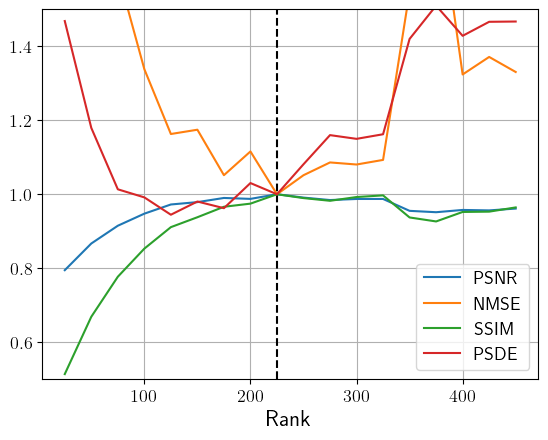

In [6]:
DNS_case='S1'
vel_planes = [1,6,11,16,21,26,31,36,41,46,51,56,61,66,71,76]
vel_planes=[1,6,11,16,21,26,31,36,41,46,51,56]
r_vals = np.array([25,50,75,100,125,150,175,200,225,250,275,300,325,350,375, 400,425,450])
SHRED_ensembles = [0,1,2,3,4,5,6,7,8,10,11,12,13,14,15]
sensor_vals=[3]
optimal_var_val = 225 #optimal value of rank r or num_sensor, only used to mark with a dashed line in plot
full_planes=False #would always be False for DNS, but often True for Teetank
r_analysis=True #True if analysing ranks, False if analysing sensors

plot_results.plot_parameter_analysis_DNS(DNS_case, r_vals, vel_planes, sensor_vals, optimal_var_val, SHRED_ensembles, full_planes, r_analysis, singular_val_energy=False, comp_rate=False, val_index=9)

### Case S2

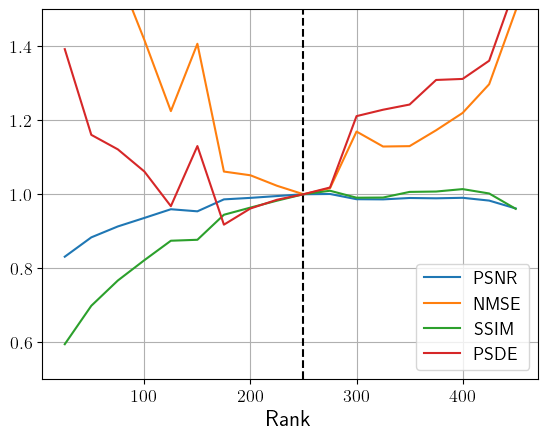

In [7]:
DNS_case='S2'
vel_planes = [1,6,11,16,21,26,31,36,41,46,51,56,61,66,71,76]
r_vals = np.array([25,50,75,100,125,150,175,200,225,250,275,300,325,350,375, 400,425,450])
SHRED_ensembles = [1,3,4,7,9,8]
sensor_vals=[3]
optimal_var_val = 250 #optimal value of rank r or num_sensor, only used to mark with a dashed line in plot
full_planes=False #would always be False for DNS, but often True for Teetank
r_analysis=True #True if analysing ranks, False if analysing sensors

plot_results.plot_parameter_analysis_DNS(DNS_case, r_vals, vel_planes, sensor_vals, optimal_var_val, SHRED_ensembles, full_planes, r_analysis, singular_val_energy=False, comp_rate=False, val_index=10)

### Case E1

  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
   P25 |   79.989 |   77.921 |   75.214 |   75.2
(4,)
sensors 3 | r 25 | plane 2 | NMSE 0.12234474976606521 | SSIM 0.45586743958862364
sensors 3 | r 25 | plane 3 | NMSE 0.1717446272127148 | SSIM 0.3792225679883567
sensors 3 | r 25 | plane 4 | NMSE 0.16572411563383 | SSIM 0.3675669377503098
sensors 3 | r 25 | plane 5 | NMSE 0.26398477889231103 | SSIM 0.362157987862016
  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
   P25 |   80.967 |   79.469 |   76.972 |   77.0
(4,)
sensors 3 | r 50 | plane 2 | NMSE 0.09670473445131804 | SSIM 0.5091436473324484
sensors 3 | r 50 | plane 3 | NMSE 0.13285163397044472 | SSIM 0.43783010311309595
sensors 3 | r 50 | plane 4 | NMSE 0.12622867750208455 | SSIM 0.43112397511567996
sensors 3 | r 50 | plane 5 | NMSE 0.21570917566370484 | SSIM 0.4097909446243371
  Case |     E_01 |     E_05 |     E_10 |  Err %
-----

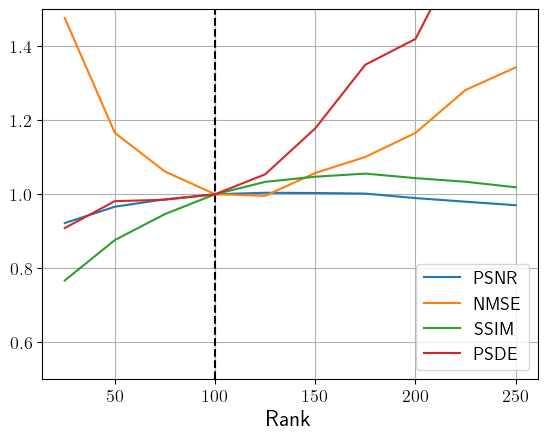

In [8]:
exp_case='E1'
vel_planes=[2,3,4,5]
r_vals = np.array([25,50,75,100,125,150,175,200,225,250])
SHRED_ensembles = [1,2,3,4,5,6,7,8,9,10] #leave 4 and 1
sensor_vals=[3]
optimal_var_val = 100 #optimal value of rank r or num_sensor, only used to mark with a dashed line in plot
full_planes=True #would always be False for DNS, but often True for Teetank
r_analysis=True #True if analysing ranks, False if analysing sensors
experimental_ens = 3

plot_results.plot_parameter_analysis_exp(exp_case, [experimental_ens], r_vals, vel_planes, sensor_vals, optimal_var_val, SHRED_ensembles, full_planes, r_analysis, singular_val_energy=False, comp_rate=False, val_index=4)

### Case E2

  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
   P50 |   77.421 |   75.699 |   74.056 |   74.1
(4,)
sensors 3 | r 25 | plane 2 | NMSE 0.12119430713877215 | SSIM 0.4346512770749912
sensors 3 | r 25 | plane 3 | NMSE 0.1842957808255409 | SSIM 0.37431351924607525
sensors 3 | r 25 | plane 4 | NMSE 0.1718839553914281 | SSIM 0.36502745629686967
sensors 3 | r 25 | plane 5 | NMSE 0.23052544902173935 | SSIM 0.37168303903950817
  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
   P50 |   74.572 |   73.952 |   72.919 |   72.9
(4,)
sensors 3 | r 50 | plane 2 | NMSE 0.10899160863058119 | SSIM 0.4606521354656278
sensors 3 | r 50 | plane 3 | NMSE 0.16194426652690547 | SSIM 0.40625091067729857
sensors 3 | r 50 | plane 4 | NMSE 0.14742053141461628 | SSIM 0.40056966170990577
sensors 3 | r 50 | plane 5 | NMSE 0.21027445814518847 | SSIM 0.3977556128229696
  Case |     E_01 |     E_05 |     E_10 |  Err %


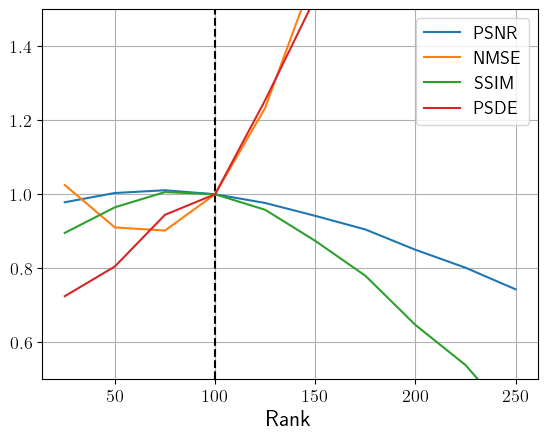

In [9]:
exp_case='E2'
vel_planes=[2,3,4,5]
r_vals = np.array([25,50,75,100,125,150,175,200,225,250])
SHRED_ensembles = [1,2,3,4,5,6,7,8,9,10] #leave 4 and 1
sensor_vals=[3]
optimal_var_val = 100 #optimal value of rank r or num_sensor, only used to mark with a dashed line in plot
full_planes=True #would always be False for DNS, but often True for T-tank
r_analysis=True #True if analysing ranks, False if analysing sensors
experimental_ens = 3

plot_results.plot_parameter_analysis_exp(exp_case, [experimental_ens], r_vals, vel_planes, sensor_vals, optimal_var_val, SHRED_ensembles, full_planes, r_analysis, singular_val_energy=False, comp_rate=False, val_index=4)


## Sensor dependency

### Case S1

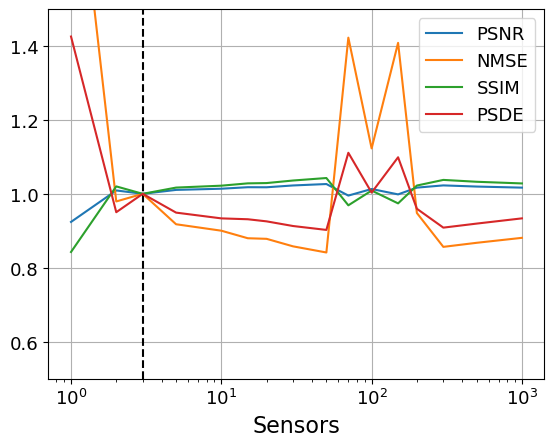

In [5]:
DNS_case='S1'
vel_planes = [1,6,11,16,21,26,31,36,41,46,51,56]#,61,66,71,76]
r_vals = r_vals = np.array([225])
SHRED_ensembles = np.arange(101,129)
sensor_vals=[1,2,3,5,10,15,20,30,50,70,100,150,200,300,500,1000]
optimal_var_val = 3 #optimal value of rank r or num_sensor, only used to mark with a dashed line in plot
full_planes=False #would always be False for DNS, but often True for Teetank
r_analysis=False #True if analysing ranks, False if analysing sensors

plot_results.plot_parameter_analysis_DNS(DNS_case, r_vals, vel_planes, sensor_vals, optimal_var_val, SHRED_ensembles, full_planes, r_analysis, singular_val_energy=False, comp_rate=False, log=True, val_index=3 )

### Case S2

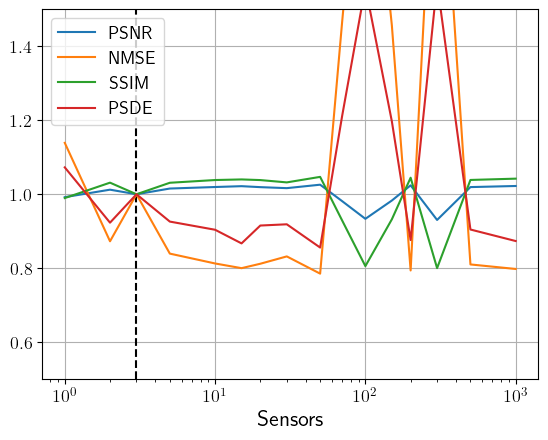

In [14]:
DNS_case='S2'
vel_planes = [1,6,11,16,21,26,31,36,41,46,51,56,61,66,71,76]
r_vals = r_vals = np.array([250])
SHRED_ensembles = [101,102,103, 104, 106,107,108,109]
sensor_vals=[1,2,3,5,10,15,20,30,50,70,100,150,200,300,500,1000]
optimal_var_val = 3 #optimal value of rank r or num_sensor, only used to mark with a dashed line in plot
full_planes=False #would always be False for DNS, but often True for Teetank
r_analysis=False #True if analysing ranks, False if analysing sensors

plot_results.plot_parameter_analysis_DNS(DNS_case, r_vals, vel_planes, sensor_vals, optimal_var_val, SHRED_ensembles, full_planes, r_analysis, singular_val_energy=False, comp_rate=False, log=True, val_index=3)

### Case E1

  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
   P25 |   31.930 |   41.070 |   40.022 |   40.0
(4,)
sensors 1 | r 100 | plane 2 | NMSE 0.6027720102048015 | SSIM 0.22735951937014898
sensors 1 | r 100 | plane 3 | NMSE 0.30298383736505563 | SSIM 0.3940667748542931
sensors 1 | r 100 | plane 4 | NMSE 0.39916530520512883 | SSIM 0.3544265055974343
sensors 1 | r 100 | plane 5 | NMSE 0.5402072107556095 | SSIM 0.24900131713318538
  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
   P25 |   56.897 |   61.051 |   58.208 |   58.2
(4,)
sensors 2 | r 100 | plane 2 | NMSE 0.3135627517963079 | SSIM 0.38576074670990346
sensors 2 | r 100 | plane 3 | NMSE 0.1255925098682684 | SSIM 0.4951555446303204
sensors 2 | r 100 | plane 4 | NMSE 0.32155033213565826 | SSIM 0.38992281706572396
sensors 2 | r 100 | plane 5 | NMSE 0.4031554052024403 | SSIM 0.32041251713940466
  Case |     E_01 |     E_05 |     E_10 |  E

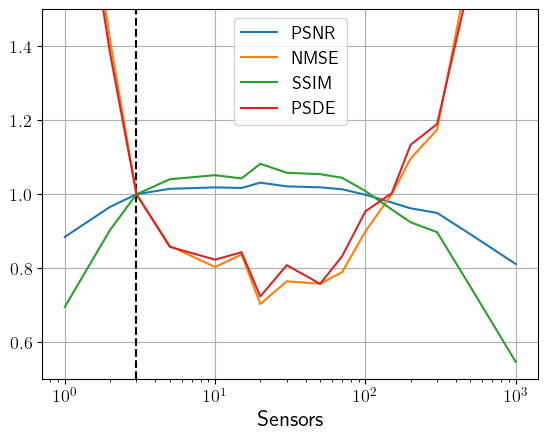

In [10]:
exp_case='E1'
vel_planes=[2,3,4,5]
r_vals = np.array([100])
SHRED_ensembles = np.arange(101,121) 
sensor_vals=[1,2,3,5,10,15,20,30,50,70,100,150,200,300,500,1000]
optimal_var_val = 3 #optimal value of rank r or num_sensor, only used to mark with a dashed line in plot
full_planes=True #would always be False for DNS, but often True for T-tank
r_analysis=False #True if analysing ranks, False if analysing sensors
experimental_ens = 13





'''RUN ENSEMBLE OF SHRED'''


plot_results.plot_parameter_analysis_exp(exp_case, [experimental_ens], r_vals, vel_planes, sensor_vals, optimal_var_val, SHRED_ensembles, full_planes, r_analysis, singular_val_energy=False, comp_rate=False, log=True)

### Case E2

  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
   P50 |   12.017 |   16.530 |   19.836 |   19.8
(4,)
sensors 1 | r 100 | plane 2 | NMSE 0.8412407856668314 | SSIM 0.1057335369359855
sensors 1 | r 100 | plane 3 | NMSE 0.6579166061906447 | SSIM 0.16391776308270722
sensors 1 | r 100 | plane 4 | NMSE 0.8200584529787311 | SSIM 0.10832863511924344
sensors 1 | r 100 | plane 5 | NMSE 0.5890635293174644 | SSIM 0.2366602075387735
  Case |     E_01 |     E_05 |     E_10 |  Err %
--------------------------------------------------
   P50 |   13.893 |   30.675 |   34.244 |   34.2
(4,)
sensors 2 | r 100 | plane 2 | NMSE 0.8209280897927878 | SSIM 0.11836185567027527
sensors 2 | r 100 | plane 3 | NMSE 0.28451211294048157 | SSIM 0.35488523233128816
sensors 2 | r 100 | plane 4 | NMSE 0.5513496361983463 | SSIM 0.2334905128019813
sensors 2 | r 100 | plane 5 | NMSE 0.4048623758067319 | SSIM 0.3269868461573511
  Case |     E_01 |     E_05 |     E_10 |  Err 

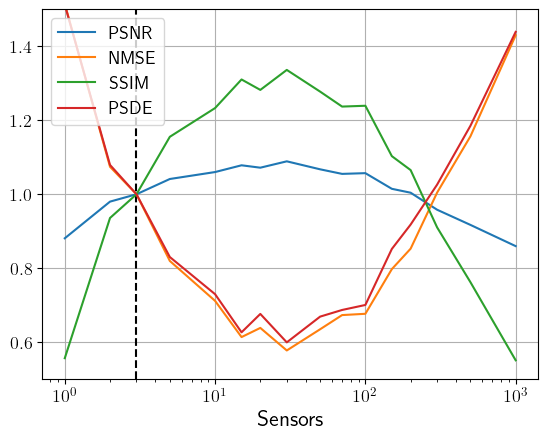

In [11]:
exp_case='E2'
vel_planes=[2,3,4,5]
r_vals = np.array([100])
SHRED_ensembles = np.arange(101,121) 
sensor_vals=[1,2,3,5,10,15,20,30,50,70,100,150,200,300,500,1000]
optimal_var_val = 3 #optimal value of rank r or num_sensor, only used to mark with a dashed line in plot
full_planes=True #would always be False for DNS, but often True for T-tank
r_analysis=False #True if analysing ranks, False if analysing sensors
experimental_ens = 13





'''RUN ENSEMBLE OF SHRED'''


plot_results.plot_parameter_analysis_exp(exp_case, [experimental_ens], r_vals, vel_planes, sensor_vals, optimal_var_val, SHRED_ensembles, full_planes, r_analysis, singular_val_energy=False, comp_rate=False, log=True)
